# Two-State Two-Action Mean-Field Control
## Simplex- versus logit-perturbed MF-REINFORCE

This notebook compares two perturbed MF-REINFORCE estimators on the two-state, two-action mean-field control benchmark. The policy is a stationary two-logit Bernoulli policy, with one move logit per state.

### 1. Benchmark

The state and action spaces are
$$
\mathcal X=\{0,1\}, \qquad \mathcal A=\{\mathrm{ST},\mathrm{MV}\}.
$$
Action $\mathrm{ST}$ leaves the state unchanged. Action $\mathrm{MV}$ switches from $x$ to $1-x$ with probability $\lambda_x$.

The running and terminal rewards are
$$
r(x,a,\mu)=\mathbf 1_{\{x=1\}}-\mu(1)^2-\kappa W_1(\mu,\bar\mu), \qquad g(x,\mu)=r(x,\mu),
$$
with $\lambda_0=0.5$, $\lambda_1=0.8$, $\kappa=10$, and $\bar\mu=(0.6,0.4)$. On $\{0,1\}$, $W_1(\mu,\bar\mu)=|\mu(1)-0.4|$.

The optimal stationary policy is known:
$$
\pi^\star(\mathrm{ST}\mid 0)=0.2, \qquad \pi^\star(\mathrm{ST}\mid 1)=0.25.
$$
It sends every initial population law to $\bar\mu$ after one step. For the fixed validation law $\mu_0^{\mathrm{val}}=(0.2,0.8)$, the exact optimal value is $J^\star=-3.36$.

### 2. Perturbation Comparison

| Method | Perturbed population argument | Auxiliary sensitivity |
|---|---|---|
| Simplex | $M_t^{\lambda,\theta}=(1-\lambda)\mu_t^\theta+\lambda q_t$ | $D_t^\theta=\nabla_\theta\mu_t^\theta$ |
| Logits | $M_t^{\varepsilon,\theta}=\operatorname{softmax}(\log\mu_t^\theta+\varepsilon\Lambda_t)$ | $\nabla_\theta\operatorname{logit}(\mu_t^\theta)$ |

The raw perturbation parameters $\lambda$ and $\varepsilon$ are not directly comparable. The notebook reports both native-parameter results and matched-radius summaries using the expected total-variation perturbation radius.

For the simplex perturbation, the sampled law is
$$
M_t^{\lambda,\theta}=(1-\lambda)\mu_t^\theta+\lambda q_t,
$$
so, pathwise,
$$
d_{\mathrm{TV}}(M_t^{\lambda,\theta},\mu_t^\theta)
=\lambda d_{\mathrm{TV}}(q_t,\mu_t^\theta)\leq \lambda.
$$
The logit perturbation has no matching pathwise radius bound; below we report its empirical total-variation size and compare the mean against the reference scale $\varepsilon/2$.

### 3. Simulator Budget

Let $B$ be the main trajectory batch size, $n$ the auxiliary or inner batch size, $T$ the horizon, and $\widetilde N$ the particle count for the unperturbed population flow. The simulated-transition counts per update are
$$
C_{\mathrm{simp}}=T(B+n), \qquad
C_{\mathrm{logit}}=BT+Bn\frac{T(T+1)}{2}.
$$
Particle-flow experiments add $\widetilde N T$ transitions to both methods.

### 4. Experiments

1. **Same parameters, exact flow.** Both methods use $(B,n)=(200,10)$.
2. **Equal simulator budget, exact flow.** Logits uses $(B,n)=(200,10)$ and simplex uses $(B,n)=(2800,400)$ for $T=2$.
3. **Equal simulator budget, particle flow.** Repeat the equal-budget particle-flow comparison for $T\in\{2,5,10\}$ with $\widetilde N=200$.

All comparisons use paired initializations, paired training-law sequences, identical optimizer settings, and the same evaluation schedule.

### 5. Reported Metrics

The notebook reports exact validation value, optimality gap, policy errors, population-flow tracking error, gradient-estimator bias and variance diagnostics, simulator-transition counts, and wall-clock runtime.


## Imports and Runtime


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple
import copy
import random
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = (ROOT / "..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from mfc.algorithms import SimplexPerturbedMFREINFORCE, LogitsPerturbedMFREINFORCE
from mfc.environments import TwoStateMFC, TwoStateConfig


## Notebook Helpers


### Formatting, Seeds, and Cost Helpers


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)


set_seed(0)
print(f"device: {device}")

def format_runtime(seconds: Optional[float]) -> str:
    if seconds is None:
        return "not set"
    seconds = float(seconds)
    hours, remainder = divmod(int(seconds), 3600)
    minutes, secs = divmod(remainder, 60)
    if hours:
        return f"{hours:d}h {minutes:02d}m {secs:02d}s"
    if minutes:
        return f"{minutes:d}m {secs:02d}s"
    return f"{seconds:.1f}s"

def std_ddof(n: int) -> int:
    return 1 if n > 1 else 0

def safe_name(name: str) -> str:
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in name).strip("_") or "twostate"

def aligned_validation_history(runs):
    min_len = min(len(run["history"]["validation_value"]) for run in runs)
    episodes = np.asarray(runs[0]["history"]["episode"][:min_len], dtype=float)
    values = np.asarray([run["history"]["validation_value"][:min_len] for run in runs], dtype=float)
    return episodes, values

def aligned_history_metric(runs, key: str):
    min_len = min(len(run["history"].get(key, [])) for run in runs)
    if min_len == 0:
        return np.asarray([]), np.asarray([])
    episodes = np.asarray(runs[0]["history"]["episode"][:min_len], dtype=float)
    values = np.asarray([run["history"][key][:min_len] for run in runs], dtype=float)
    return episodes, values

def simulator_transitions_per_update(
    algorithm_name: str,
    horizon: int,
    B: int,
    n_aux_or_inner: int,
    flow_mode: str = "exact",
    flow_particles: int = 0,
) -> int:
    if algorithm_name == "Simplex":
        core = (B + n_aux_or_inner) * horizon
    elif algorithm_name == "Logits":
        core = B * horizon + B * n_aux_or_inner * horizon * (horizon + 1) // 2
    else:
        raise ValueError(f"Unknown algorithm_name={algorithm_name!r}.")

    flow_cost = 0 if flow_mode == "exact" else flow_particles * horizon
    return int(core + flow_cost)

def simulator_cost_table(
    horizon: int,
    flow_mode: str,
    budgets: Dict[str, Dict[str, int]],
    flow_particles: int = 0,
) -> pd.DataFrame:
    rows = []
    simplex_cost = simulator_transitions_per_update(
        "Simplex",
        horizon,
        budgets["Simplex"]["B"],
        budgets["Simplex"]["n"],
        flow_mode=flow_mode,
        flow_particles=flow_particles,
    )
    for algorithm_name in ["Simplex", "Logits"]:
        budget = budgets[algorithm_name]
        cost = simulator_transitions_per_update(
            algorithm_name,
            horizon,
            budget["B"],
            budget["n"],
            flow_mode=flow_mode,
            flow_particles=flow_particles,
        )
        rows.append(
            {
                "algorithm": algorithm_name,
                "B": budget["B"],
                "n": budget["n"],
                "horizon": horizon,
                "flow_mode": flow_mode,
                "flow_particles": flow_particles if flow_mode == "particle" else 0,
                "simulator_transitions_per_update": cost,
                "ratio_vs_simplex": cost / simplex_cost,
            }
        )
    return pd.DataFrame(rows).set_index("algorithm")

def particle_equal_budget_for_horizon(horizon: int) -> Dict[str, Dict[str, int]]:
    logit_budget = {"B": 200, "n": 10}
    simplex_total = logit_budget["B"] + logit_budget["B"] * logit_budget["n"] * (horizon + 1) // 2
    simplex_n = simplex_total // 8
    return {
        "Simplex": {"B": simplex_total - simplex_n, "n": simplex_n},
        "Logits": logit_budget,
    }


device: cuda


### Run Plans and Controls


In [3]:
def fixed_validation_law(config: TwoStateConfig) -> torch.Tensor:
    return torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)

def sample_twostate_initial_laws(config: TwoStateConfig, count: int) -> torch.Tensor:
    mu1 = config.low + (config.high - config.low) * torch.rand(
        count,
        dtype=config.dtype,
        device=config.device,
    )
    return torch.stack([1.0 - mu1, mu1], dim=-1).detach().cpu()

def prepare_paired_run_plans(config: TwoStateConfig, seed_base: int = 11_000, training_runs: Optional[int] = None):
    n_runs = config.training_runs if training_runs is None else training_runs
    plans = []
    for run_idx in range(n_runs):
        seed = seed_base + run_idx
        set_seed(seed)
        plans.append(
            {
                "run_idx": run_idx,
                "seed": seed,
                "initial_control": {"theta": torch.zeros(2, dtype=config.dtype, device=config.device).cpu()},
                "initial_laws": sample_twostate_initial_laws(config, config.n_train),
            }
        )
    return plans

def payload_from_record(record: Dict[str, object]) -> Dict[str, torch.Tensor]:
    return {"theta": record["theta"].detach().cpu().clone()}

def load_theta(config: TwoStateConfig, payload: Dict[str, torch.Tensor], trainable: bool = True):
    theta = payload["theta"].to(dtype=config.dtype, device=config.device).detach().clone()
    return torch.nn.Parameter(theta) if trainable else theta

def theta_for_estimator(theta):
    return theta.detach() if isinstance(theta, torch.nn.Parameter) else theta

def assign_ascent_gradient(theta: torch.nn.Parameter, grad_hat: torch.Tensor) -> None:
    theta.grad = -grad_hat.detach().clone().reshape_as(theta)
    
def training_population_flow(
    env: TwoStateMFC,
    algorithm,
    theta,
    mu0: torch.Tensor,
    horizon: int,
    flow_mode: str,
    flow_particles: int,
) -> torch.Tensor:
    ctrl = theta_for_estimator(theta)
    if flow_mode == "exact":
        with torch.no_grad():
            return env.exact_population_flow(ctrl, mu0, horizon).detach()
    if flow_mode == "particle":
        return algorithm.estimate_population_flow(ctrl, mu0, flow_particles, horizon=horizon).detach()
    raise ValueError(f"Unknown flow_mode={flow_mode!r}.")


### Training and Scenario Runner


In [4]:
def reference_metrics(env: TwoStateMFC, theta, mu0: torch.Tensor, horizon: int) -> Dict[str, object]:
    ctrl = theta_for_estimator(theta)
    with torch.no_grad():
        flow = env.exact_population_flow(ctrl, mu0, horizon).detach()
        value = env.exact_value(ctrl, mu0, horizon).detach()
        policy = env.policy_probs(ctrl).detach()
        optimal = env.optimal_policy().detach()
        st_errors = (policy[:, 0] - optimal[:, 0]).abs()
        flow_error = (flow[1:, 1] - env.target_B[1]).abs().mean()
    return {
        "value": float(value.item()),
        "policy": policy.cpu(),
        "optimal_policy": optimal.cpu(),
        "final_distribution": flow[-1].cpu(),
        "flow": flow.cpu(),
        "policy_error_st_0": float(st_errors[0].item()),
        "policy_error_st_1": float(st_errors[1].item()),
        "policy_error_mean": float(st_errors.mean().item()),
        "flow_error": float(flow_error.item()),
        "err_pi_st_0": float(st_errors[0].item()),
        "err_pi_st_1": float(st_errors[1].item()),
    }

def record_numeric_history(history: Dict[str, List[float]], metrics: Dict[str, object]) -> None:
    for key, value in metrics.items():
        if isinstance(value, (int, float, np.integer, np.floating)):
            history.setdefault(key, []).append(float(value))

def train_twostate_method(
    method: str,
    config: TwoStateConfig,
    perturbation_values,
    budget: Dict[str, int],
    run_plans,
    flow_mode: str,
    flow_particles: int,
    train_horizon: int,
    validation_horizon: int,
    label: str,
    early_stopping_patience: Optional[int] = None,
    early_stopping_min_delta: float = 0.0,
    max_runtime_seconds: Optional[float] = None,
    save_dir: Path = ROOT / "models" / "TwoStateExactParticle",
):
    algorithm_name = "Simplex" if method == "simplex" else "Logits"
    B = int(budget["B"])
    n_aux_or_inner = int(budget["n"])
    transitions_per_update = simulator_transitions_per_update(
        algorithm_name,
        train_horizon,
        B,
        n_aux_or_inner,
        flow_mode=flow_mode,
        flow_particles=flow_particles,
    )
    save_root = Path(save_dir) / safe_name(label) / safe_name(algorithm_name)
    save_root.mkdir(parents=True, exist_ok=True)
    fixed_mu0 = fixed_validation_law(config)
    results = {}

    for perturbation in perturbation_values:
        perturbation = float(perturbation)
        results[perturbation] = []
        eps_start = time.perf_counter()
        for run_idx, plan in enumerate(run_plans):
            set_seed(plan["seed"])
            env = TwoStateMFC(config)
            theta = load_theta(config, plan["initial_control"], trainable=True)
            optimizer = torch.optim.Adam([theta], lr=config.lr)
            algorithm = SimplexPerturbedMFREINFORCE(env) if method == "simplex" else LogitsPerturbedMFREINFORCE(env)
            history: Dict[str, List[float]] = {
                "episode": [],
                "validation_value": [],
                "train_return_mean": [],
                "grad_norm": [],
                "elapsed_seconds": [],
            }
            run_start = time.perf_counter()
            stop_reason = "completed"
            episodes_completed = 0
            best_validation = -float("inf")
            best_episode = None
            best_theta = None

            progress = tqdm(range(config.n_train), desc=f"{label} {algorithm_name} p={perturbation} run={run_idx}")
            for episode in progress:
                if max_runtime_seconds is not None and time.perf_counter() - run_start >= max_runtime_seconds:
                    stop_reason = f"max_runtime_{format_runtime(max_runtime_seconds)}"
                    break

                mu0 = plan["initial_laws"][episode].to(dtype=config.dtype, device=config.device)
                mu_flow = training_population_flow(env, algorithm, theta, mu0, train_horizon, flow_mode, flow_particles)
                ctrl = theta_for_estimator(theta)

                if method == "simplex":
                    D_hat = algorithm.estimate_sensitivity(ctrl, mu_flow, perturbation, n_aux_or_inner)
                    grad_hat, diag = algorithm.gradient_estimate(ctrl, mu_flow, D_hat, perturbation, B, baseline="batch_mean")
                else:
                    grad_hat, diag = algorithm.gradient_estimate(
                        ctrl,
                        mu0,
                        perturbation,
                        B,
                        n_aux_or_inner,
                        flow_particles=1,
                        horizon=train_horizon,
                        mu_flow=mu_flow,
                    )

                optimizer.zero_grad(set_to_none=True)
                assign_ascent_gradient(theta, grad_hat)
                optimizer.step()
                episodes_completed = episode + 1

                if episode % config.validate_every == 0 or episode == config.n_train - 1:
                    metrics = reference_metrics(env, theta, fixed_mu0, validation_horizon)
                    validation_value = metrics["value"]
                    history["episode"].append(episode)
                    history["validation_value"].append(validation_value)
                    history["train_return_mean"].append(float(diag["mean_return"].detach().item()))
                    history["grad_norm"].append(float(diag["grad_norm"].detach().item()))
                    history["elapsed_seconds"].append(time.perf_counter() - run_start)
                    record_numeric_history(history, metrics)
                    progress.set_postfix(value=f"{validation_value:.4g}", grad=f"{history['grad_norm'][-1]:.3g}")

                    if validation_value > best_validation + early_stopping_min_delta:
                        best_validation = validation_value
                        best_episode = episode
                        best_theta = theta.detach().cpu().clone()
                    else:
                        pass

                    if early_stopping_patience is not None:
                        checks_since_best = len(history["validation_value"]) - 1 - history["validation_value"].index(best_validation)
                        if checks_since_best >= early_stopping_patience:
                            stop_reason = "early_stopping"
                            break

            final_metrics = reference_metrics(env, theta, fixed_mu0, validation_horizon)
            theta_cpu = theta.detach().cpu().clone()
            record = {
                "algorithm": algorithm_name,
                "flow_mode": flow_mode,
                "flow_particles": flow_particles if flow_mode == "particle" else 0,
                "perturbation": perturbation,
                "epsilon": perturbation,
                "run_idx": run_idx,
                "seed": plan["seed"],
                "theta": theta_cpu,
                "final_policy": final_metrics["policy"],
                "optimal_policy": final_metrics["optimal_policy"],
                "final_distribution": final_metrics["final_distribution"],
                "history": history,
                "final_value": final_metrics["value"],
                "reference_metrics": final_metrics,
                "runtime_seconds": time.perf_counter() - run_start,
                "episodes_completed": episodes_completed,
                "main_trajectories": B,
                "auxiliary_trajectories": n_aux_or_inner,
                "simulator_transitions_per_update": transitions_per_update,
                "total_simulator_transitions": transitions_per_update * episodes_completed,
                "stop_reason": stop_reason,
                "best_validation_value": best_validation,
                "best_episode": best_episode,
                "best_theta": best_theta,
            }
            save_path = save_root / f"{flow_mode}_p_{str(perturbation).replace('.', 'p')}_run_{run_idx}.pt"
            record["save_path"] = str(save_path)
            torch.save({"config": config, "record": record}, save_path)
            results[perturbation].append(record)
            print(
                f"{label} {algorithm_name} p={perturbation} run={run_idx} "
                f"value={record['final_value']:.6g} cost/update={transitions_per_update} "
                f"runtime={format_runtime(record['runtime_seconds'])}"
            )
        print(f"{label} {algorithm_name} p={perturbation} completed in {format_runtime(time.perf_counter() - eps_start)}")
    return results

def run_twostate_scenario(
    name: str,
    config: TwoStateConfig,
    simplex_lambdas,
    logit_epsilons,
    budgets: Dict[str, Dict[str, int]],
    run_plans,
    flow_mode: str,
    flow_particles: int = 0,
    train_horizon: Optional[int] = None,
    validation_horizon: Optional[int] = None,
    early_stopping_patience: Optional[int] = None,
    max_runtime_seconds: Optional[float] = None,
):
    train_horizon = config.T if train_horizon is None else train_horizon
    validation_horizon = config.T if validation_horizon is None else validation_horizon
    costs = simulator_cost_table(train_horizon, flow_mode, budgets, flow_particles=flow_particles)
    display(costs.round(4))
    simplex_results = train_twostate_method(
        "simplex",
        config,
        simplex_lambdas,
        budgets["Simplex"],
        run_plans,
        flow_mode,
        flow_particles,
        train_horizon,
        validation_horizon,
        label=name,
        early_stopping_patience=early_stopping_patience,
        max_runtime_seconds=max_runtime_seconds,
    )
    logits_results = train_twostate_method(
        "logits",
        config,
        logit_epsilons,
        budgets["Logits"],
        run_plans,
        flow_mode,
        flow_particles,
        train_horizon,
        validation_horizon,
        label=name,
        early_stopping_patience=early_stopping_patience,
        max_runtime_seconds=max_runtime_seconds,
    )
    return {
        "name": name,
        "flow_mode": flow_mode,
        "flow_particles": flow_particles if flow_mode == "particle" else 0,
        "budgets": copy.deepcopy(budgets),
        "costs": costs,
        "train_horizon": train_horizon,
        "validation_horizon": validation_horizon,
        "results": {"Simplex": simplex_results, "Logits": logits_results},
    }


### Calibration, Metrics, and Plotting


In [5]:
def sample_simplex_q(config: TwoStateConfig, n: int) -> torch.Tensor:
    u = config.q_sigma * torch.randn(n, 1, dtype=config.dtype, device=config.device)
    logits = torch.cat([u, torch.zeros(n, 1, dtype=config.dtype, device=config.device)], dim=-1)
    q = torch.softmax(logits, dim=-1).clamp_min(config.q_clip)
    return q / q.sum(dim=-1, keepdim=True)

def calibrate_perturbation_radii(
    config: TwoStateConfig,
    reference_laws: torch.Tensor,
    simplex_values,
    logit_values,
    num_samples: int = 20_000,
) -> pd.DataFrame:
    reference_laws = reference_laws.to(dtype=config.dtype, device=config.device)
    index = torch.randint(reference_laws.shape[0], (num_samples,), device=config.device)
    mu = reference_laws[index].clamp_min(config.q_clip)
    mu = mu / mu.sum(dim=-1, keepdim=True)
    q = sample_simplex_q(config, num_samples)
    lambdas = torch.randn(num_samples, 2, dtype=config.dtype, device=config.device)
    log_mu = torch.log(mu)
    rows = []

    for value in simplex_values:
        perturbed = (1.0 - float(value)) * mu + float(value) * q
        radii = 0.5 * (mu - perturbed).abs().sum(dim=-1).detach().cpu().numpy()
        rows.append(
            {
                "algorithm": "Simplex",
                "parameter": float(value),
                "tv_mean": radii.mean(),
                "tv_median": np.median(radii),
                "tv_std": radii.std(ddof=0),
                "tv_p10": np.quantile(radii, 0.10),
                "tv_p90": np.quantile(radii, 0.90),
            }
        )
    for value in logit_values:
        perturbed = torch.softmax(log_mu + float(value) * lambdas, dim=-1)
        radii = 0.5 * (mu - perturbed).abs().sum(dim=-1).detach().cpu().numpy()
        rows.append(
            {
                "algorithm": "Logits",
                "parameter": float(value),
                "tv_mean": radii.mean(),
                "tv_median": np.median(radii),
                "tv_std": radii.std(ddof=0),
                "tv_p10": np.quantile(radii, 0.10),
                "tv_p90": np.quantile(radii, 0.90),
            }
        )
    return pd.DataFrame(rows)

def metric_from_run(run: Dict[str, object], key: str) -> float:
    if key in run.get("reference_metrics", {}):
        return float(run["reference_metrics"][key])
    return float(run[key])

def summarize_metric_rows(result_groups, metric_keys: List[str]) -> pd.DataFrame:
    rows = []
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            row = {"algorithm": algorithm_name, "parameter": float(perturbation)}
            ddof = std_ddof(len(runs))
            for key in metric_keys:
                values = np.asarray([metric_from_run(run, key) for run in runs], dtype=float)
                row[f"{key}_mean"] = values.mean()
                row[f"{key}_std"] = values.std(ddof=ddof)
            for key in [
                "runtime_seconds",
                "episodes_completed",
                "best_validation_value",
                "main_trajectories",
                "auxiliary_trajectories",
                "simulator_transitions_per_update",
                "total_simulator_transitions",
            ]:
                if key in runs[0]:
                    row[f"{key}_mean"] = np.mean([run[key] for run in runs])
            rows.append(row)
    return pd.DataFrame(rows).set_index(["algorithm", "parameter"]).sort_index()

def interpolate_metric(x: np.ndarray, y: np.ndarray, target_x: np.ndarray) -> np.ndarray:
    order = np.argsort(x)
    x = np.asarray(x, dtype=float)[order]
    y = np.asarray(y, dtype=float)[order]
    unique_x, inverse = np.unique(x, return_inverse=True)
    if len(unique_x) != len(x):
        y_accum = np.zeros_like(unique_x, dtype=float)
        counts = np.zeros_like(unique_x, dtype=float)
        for idx, value in zip(inverse, y):
            y_accum[idx] += value
            counts[idx] += 1
        x = unique_x
        y = y_accum / counts
    return np.interp(target_x, x, y, left=np.nan, right=np.nan)

def matched_radius_summary(result_groups, calibration: pd.DataFrame, metric_key: str = "value", num_points: int = 7):
    rows = []
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            radius_row = calibration[
                (calibration["algorithm"] == algorithm_name) &
                np.isclose(calibration["parameter"], float(perturbation))
            ]
            if radius_row.empty:
                continue
            values = np.asarray([metric_from_run(run, metric_key) for run in runs], dtype=float)
            rows.append(
                {
                    "algorithm": algorithm_name,
                    "parameter": float(perturbation),
                    "radius": float(radius_row.iloc[0]["tv_mean"]),
                    f"{metric_key}_mean": values.mean(),
                    f"{metric_key}_std": values.std(ddof=std_ddof(len(values))),
                }
            )
    native = pd.DataFrame(rows).sort_values(["algorithm", "radius"])
    if native.empty or native["algorithm"].nunique() < 2:
        return pd.DataFrame(), native
    bounds = native.groupby("algorithm")["radius"].agg(["min", "max"])
    lo = bounds["min"].max()
    hi = bounds["max"].min()
    if lo > hi:
        return pd.DataFrame(), native
    radius_points = np.linspace(lo, hi, num_points)
    matched_rows = []
    for algorithm_name, group in native.groupby("algorithm"):
        estimates = interpolate_metric(group["radius"].to_numpy(), group[f"{metric_key}_mean"].to_numpy(), radius_points)
        for radius, estimate in zip(radius_points, estimates):
            matched_rows.append({"algorithm": algorithm_name, "matched_tv_radius": radius, f"{metric_key}_mean_interp": estimate})
    return pd.DataFrame(matched_rows).set_index(["algorithm", "matched_tv_radius"]), native.set_index(["algorithm", "parameter"])

def plot_validation_groups(result_groups, title: str):
    line_styles = {"Simplex": "-", "Logits": "--"}
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            episodes, values = aligned_validation_history(runs)
            mean = values.mean(axis=0)
            std = values.std(axis=0, ddof=std_ddof(len(runs)))
            ax.plot(episodes, mean, linestyle=line_styles[algorithm_name], label=f"{algorithm_name}, p={perturbation}")
            ax.fill_between(episodes, mean - std, mean + std, alpha=0.12)
    ax.set_title(title)
    ax.set_xlabel("Training steps")
    ax.set_ylabel(r"$V(\mu_0)$ (mean +/- std. dev.)")
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    plt.show()

def show_twostate_results(scenario: Dict[str, object], calibration: pd.DataFrame):
    result_groups = scenario["results"]
    print(scenario["name"])
    display(scenario["costs"].round(4))
    display(calibration.round(4))
    matched, native = matched_radius_summary(result_groups, calibration, metric_key="value")
    display(native.round(6))
    display(matched.round(6))
    plot_validation_groups(result_groups, f"{scenario['name']}: validation reward")
    table = summarize_metric_rows(
        result_groups,
        ["value", "policy_error_st_0", "policy_error_st_1", "policy_error_mean", "flow_error"],
    )
    display(table.round(6))

    line_styles = {"Simplex": "-", "Logits": "--"}
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    metric_panels = [
        ("policy_error_st_0", r"$|\pi(\mathrm{ST}|0)-\pi^*(\mathrm{ST}|0)|$"),
        ("policy_error_st_1", r"$|\pi(\mathrm{ST}|1)-\pi^*(\mathrm{ST}|1)|$"),
        ("flow_error", r"$T^{-1}\sum_{t=1}^{T}|\mu_t(1)-0.4|$"),
    ]
    for ax, (metric_key, title) in zip(axes, metric_panels):
        for algorithm_name, result_group in result_groups.items():
            for perturbation, runs in result_group.items():
                episodes, values = aligned_history_metric(runs, metric_key)
                if values.size == 0:
                    continue
                mean = values.mean(axis=0)
                std = values.std(axis=0, ddof=std_ddof(len(runs)))
                ax.plot(episodes, mean, linestyle=line_styles[algorithm_name], label=f"{algorithm_name}, p={perturbation}")
                ax.fill_between(episodes, mean - std, mean + std, alpha=0.10)
        ax.set_title(title)
        ax.set_xlabel("Training steps")
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("Mean +/- std. dev.")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=4, fontsize=8)
    fig.tight_layout()
    plt.show()

def scenario_summary_table(scenario: Dict[str, object], experiment: str, horizon: Optional[int] = None) -> pd.DataFrame:
    table = summarize_metric_rows(
        scenario["results"],
        ["value", "policy_error_st_0", "policy_error_st_1", "policy_error_mean", "flow_error"],
    ).reset_index()
    table.insert(0, "experiment", experiment)
    table.insert(1, "flow_mode", scenario["flow_mode"])
    table.insert(2, "T", int(scenario["train_horizon"] if horizon is None else horizon))
    table.insert(3, "flow_particles", int(scenario["flow_particles"]))
    cost_lookup = scenario["costs"]["simulator_transitions_per_update"].to_dict()
    table["simulator_transitions_per_update"] = table["algorithm"].map(cost_lookup).astype(int)
    leading_columns = [
        "experiment",
        "flow_mode",
        "T",
        "flow_particles",
        "algorithm",
        "parameter",
        "simulator_transitions_per_update",
    ]
    return table[leading_columns + [column for column in table.columns if column not in leading_columns]]


### Exact-Gradient Diagnostics


In [6]:
def exact_gradient(env: TwoStateMFC, theta: torch.Tensor, mu0: torch.Tensor, horizon: int) -> Tuple[torch.Tensor, torch.Tensor]:
    theta_var = theta.detach().clone().requires_grad_(True)
    value = env.exact_value(theta_var, mu0, horizon)
    (grad,) = torch.autograd.grad(value, theta_var)
    return value.detach(), grad.detach().reshape(-1)

def cosine_similarity_flat(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x.flatten() @ y.flatten() / denom).item())

def gradient_diagnostic_summary(
    config: TwoStateConfig,
    payload: Dict[str, torch.Tensor],
    algorithm_name: str,
    perturbation: float,
    budget: Dict[str, int],
    mu0: torch.Tensor,
    horizon: int,
    flow_mode: str,
    flow_particles: int,
    repetitions: int,
    label: str,
) -> Dict[str, object]:
    env = TwoStateMFC(config)
    theta = load_theta(config, payload, trainable=False)
    mu0 = mu0.to(dtype=config.dtype, device=config.device)
    B = int(budget["B"])
    n_aux_or_inner = int(budget["n"])
    _, oracle_grad = exact_gradient(env, theta, mu0, horizon)
    per_estimate_transitions = simulator_transitions_per_update(
        algorithm_name,
        horizon,
        B,
        n_aux_or_inner,
        flow_mode=flow_mode,
        flow_particles=flow_particles,
    )

    samples = []
    iterator = tqdm(range(repetitions), desc=f"{label} {algorithm_name} p={perturbation}", leave=False)
    if algorithm_name == "Simplex":
        algorithm = SimplexPerturbedMFREINFORCE(env)
        for _ in iterator:
            mu_flow = training_population_flow(env, algorithm, theta, mu0, horizon, flow_mode, flow_particles)
            D_hat = algorithm.estimate_sensitivity(theta, mu_flow, float(perturbation), n_aux_or_inner)
            grad_hat, _ = algorithm.gradient_estimate(theta, mu_flow, D_hat, float(perturbation), B, baseline="batch_mean")
            samples.append(grad_hat.detach().reshape(-1))
    else:
        algorithm = LogitsPerturbedMFREINFORCE(env)
        for _ in iterator:
            mu_flow = training_population_flow(env, algorithm, theta, mu0, horizon, flow_mode, flow_particles)
            grad_hat, _ = algorithm.gradient_estimate(
                theta,
                mu0,
                float(perturbation),
                B,
                n_aux_or_inner,
                flow_particles=1,
                horizon=horizon,
                mu_flow=mu_flow,
            )
            samples.append(grad_hat.detach().reshape(-1))

    samples = torch.stack(samples)
    mean_grad = samples.mean(dim=0)
    bias = mean_grad - oracle_grad
    covariance_trace = float(samples.var(dim=0, unbiased=repetitions > 1).sum().item()) if repetitions > 1 else 0.0
    mse = ((samples - oracle_grad.unsqueeze(0)).square().sum(dim=1)).mean()
    return {
        "label": label,
        "algorithm": algorithm_name,
        "flow_mode": flow_mode,
        "flow_particles": flow_particles if flow_mode == "particle" else 0,
        "parameter": float(perturbation),
        "repetitions": repetitions,
        "B": B,
        "n_aux_or_inner": n_aux_or_inner,
        "oracle_grad_norm": float(torch.linalg.norm(oracle_grad).item()),
        "mean_grad_norm": float(torch.linalg.norm(mean_grad).item()),
        "bias_norm": float(torch.linalg.norm(bias).item()),
        "covariance_trace": covariance_trace,
        "mse": float(mse.item()),
        "cosine_to_oracle": cosine_similarity_flat(mean_grad, oracle_grad),
        "simulator_transitions_per_estimate": int(per_estimate_transitions),
        "simulator_transitions": int(per_estimate_transitions * repetitions),
    }

def run_twostate_diagnostics(
    scenario: Dict[str, object],
    config: TwoStateConfig,
    simplex_lambdas,
    logit_epsilons,
    run_plans,
    repetitions: int = 64,
) -> pd.DataFrame:
    results = scenario["results"]
    controls = [
        ("initial", run_plans[0]["initial_control"]),
        ("simplex_final_lambda_0.4", payload_from_record(results["Simplex"][0.4][0])),
        ("logits_final_epsilon_1.0", payload_from_record(results["Logits"][1.0][0])),
    ]
    rows = []
    mu0 = fixed_validation_law(config)
    for label, payload in controls:
        for perturbation in simplex_lambdas:
            rows.append(
                gradient_diagnostic_summary(
                    config,
                    payload,
                    "Simplex",
                    perturbation,
                    scenario["budgets"]["Simplex"],
                    mu0,
                    scenario["train_horizon"],
                    scenario["flow_mode"],
                    scenario["flow_particles"],
                    repetitions,
                    label,
                )
            )
        for perturbation in logit_epsilons:
            rows.append(
                gradient_diagnostic_summary(
                    config,
                    payload,
                    "Logits",
                    perturbation,
                    scenario["budgets"]["Logits"],
                    mu0,
                    scenario["train_horizon"],
                    scenario["flow_mode"],
                    scenario["flow_particles"],
                    repetitions,
                    label,
                )
            )
    return pd.DataFrame(rows)


### Perturbation-Size Verification


In [7]:
def total_variation_distance(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    return 0.5 * (p - q).abs().sum(dim=-1)


def _torch_rng_snapshot() -> Dict[str, object]:
    snapshot: Dict[str, object] = {"cpu": torch.random.get_rng_state()}
    if device.type == "cuda":
        snapshot["cuda"] = torch.cuda.get_rng_state_all()
    return snapshot


def _restore_torch_rng(snapshot: Dict[str, object]) -> None:
    torch.random.set_rng_state(snapshot["cpu"])
    if device.type == "cuda" and "cuda" in snapshot:
        torch.cuda.set_rng_state_all(snapshot["cuda"])


def _set_torch_seed(seed: int) -> None:
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)


def sample_perturbation_tv_sizes(
    config: TwoStateConfig,
    mu_flow: torch.Tensor,
    algorithm_name: str,
    parameter: float,
    samples_per_run: int,
    tolerance: float = 1e-12,
) -> Dict[str, object]:
    parameter = float(parameter)
    mu_flow = mu_flow.to(dtype=config.dtype, device=config.device).clamp_min(config.q_clip)
    mu_flow = mu_flow / mu_flow.sum(dim=-1, keepdim=True)
    time_count = int(mu_flow.shape[0])
    expanded_mu = mu_flow.unsqueeze(0).expand(samples_per_run, time_count, -1)

    if algorithm_name == "Simplex":
        q = sample_simplex_q(config, samples_per_run * time_count).reshape(samples_per_run, time_count, -1)
        perturbed = (1.0 - parameter) * expanded_mu + parameter * q
        tv_sizes = total_variation_distance(perturbed, expanded_mu)
        slack = parameter - tv_sizes
        return {
            "tv_sizes": tv_sizes.reshape(-1).detach().cpu().numpy(),
            "simplex_violation_count": int((slack < -tolerance).sum().item()),
            "simplex_min_slack": float(slack.min().detach().cpu().item()),
        }

    if algorithm_name == "Logits":
        noise = torch.randn(
            samples_per_run,
            time_count,
            int(mu_flow.shape[-1]),
            dtype=config.dtype,
            device=config.device,
        )
        perturbed = torch.softmax(torch.log(mu_flow).unsqueeze(0) + parameter * noise, dim=-1)
        tv_sizes = total_variation_distance(perturbed, expanded_mu)
        return {
            "tv_sizes": tv_sizes.reshape(-1).detach().cpu().numpy(),
            "simplex_violation_count": np.nan,
            "simplex_min_slack": np.nan,
        }

    raise ValueError(f"Unknown algorithm_name={algorithm_name!r}.")


def scenario_perturbation_size_summary(
    scenario: Dict[str, object],
    config: TwoStateConfig,
    experiment: str,
    samples_per_run: int = 20_000,
    tolerance: float = 1e-12,
) -> pd.DataFrame:
    rng_snapshot = _torch_rng_snapshot()
    rows = []
    try:
        env = TwoStateMFC(config)
        fixed_mu0 = fixed_validation_law(config)
        horizon = int(scenario["train_horizon"])
        flow_mode = str(scenario["flow_mode"])
        flow_particles = int(scenario["flow_particles"])

        for algorithm_name in ["Simplex", "Logits"]:
            algorithm = SimplexPerturbedMFREINFORCE(env) if algorithm_name == "Simplex" else LogitsPerturbedMFREINFORCE(env)
            for parameter, runs in scenario["results"][algorithm_name].items():
                tv_chunks = []
                simplex_violation_count = 0
                simplex_min_slack = float("inf")
                for run in runs:
                    verification_seed = 700_000 + int(run["seed"]) + int(round(float(parameter) * 10_000))
                    if algorithm_name == "Logits":
                        verification_seed += 100_000
                    _set_torch_seed(verification_seed)
                    theta = run["theta"].to(dtype=config.dtype, device=config.device)
                    mu_flow = training_population_flow(
                        env,
                        algorithm,
                        theta,
                        fixed_mu0,
                        horizon,
                        flow_mode,
                        flow_particles,
                    )
                    sample = sample_perturbation_tv_sizes(
                        config,
                        mu_flow,
                        algorithm_name,
                        float(parameter),
                        samples_per_run,
                        tolerance=tolerance,
                    )
                    tv_chunks.append(sample["tv_sizes"])
                    if algorithm_name == "Simplex":
                        simplex_violation_count += int(sample["simplex_violation_count"])
                        simplex_min_slack = min(simplex_min_slack, float(sample["simplex_min_slack"]))

                if not tv_chunks:
                    continue
                tv_sizes = np.concatenate(tv_chunks)
                row = {
                    "experiment": experiment,
                    "flow_mode": flow_mode,
                    "T": horizon,
                    "flow_particles": flow_particles,
                    "algorithm": algorithm_name,
                    "parameter": float(parameter),
                    "runs": len(runs),
                    "samples_per_run": int(samples_per_run),
                    "tv_mean": float(tv_sizes.mean()),
                    "tv_p90": float(np.quantile(tv_sizes, 0.90)),
                    "tv_p99": float(np.quantile(tv_sizes, 0.99)),
                    "tv_max": float(tv_sizes.max()),
                    "simulator_transitions_per_update": int(scenario["costs"].loc[algorithm_name, "simulator_transitions_per_update"]),
                    "pathwise_bound": np.nan,
                    "simplex_violation_count": np.nan,
                    "simplex_min_slack": np.nan,
                    "logit_reference_size": np.nan,
                    "logit_mean_over_reference": np.nan,
                }
                if algorithm_name == "Simplex":
                    row["pathwise_bound"] = float(parameter)
                    row["simplex_violation_count"] = simplex_violation_count
                    row["simplex_min_slack"] = simplex_min_slack
                else:
                    reference_size = float(parameter) / 2.0
                    row["logit_reference_size"] = reference_size
                    row["logit_mean_over_reference"] = row["tv_mean"] / reference_size if reference_size > 0.0 else np.nan
                rows.append(row)
    finally:
        _restore_torch_rng(rng_snapshot)

    columns = [
        "experiment",
        "flow_mode",
        "T",
        "flow_particles",
        "algorithm",
        "parameter",
        "runs",
        "samples_per_run",
        "tv_mean",
        "tv_p90",
        "tv_p99",
        "tv_max",
        "simulator_transitions_per_update",
        "pathwise_bound",
        "simplex_violation_count",
        "simplex_min_slack",
        "logit_reference_size",
        "logit_mean_over_reference",
    ]
    return pd.DataFrame(rows, columns=columns)


def display_perturbation_size_summary(table: pd.DataFrame) -> None:
    display(table.round(6))


## Common Experiment Setup


In [8]:
config = TwoStateConfig(device=device, dtype=DTYPE)
train_horizon = config.T
validation_horizon = config.T

simplex_lambdas = [0.01, 0.1, 0.2, 0.4, 0.8]
logit_epsilons = [0.01, 0.2, 0.5, 1.0, 2.0]

same_parameter_budgets = {
    "Simplex": {"B": 200, "n": 10},
    "Logits": {"B": 200, "n": 10},
}
equal_simulator_budgets = {
    "Simplex": {"B": 2800, "n": 400},
    "Logits": {"B": 200, "n": 10},
}

particle_flow_particles = 200
particle_horizons = [2, 5, 10]

early_stopping_patience = None
max_runtime_seconds = None
diagnostic_repetitions = 64
perturbation_tv_samples_per_run = 20_000
perturbation_tv_tolerance = 1e-12

twostate_run_plans = prepare_paired_run_plans(config, seed_base=11_000)
twostate_reference_laws = sample_twostate_initial_laws(config, 20_000).to(dtype=config.dtype, device=config.device)
twostate_calibration = calibrate_perturbation_radii(
    config,
    twostate_reference_laws,
    simplex_lambdas,
    logit_epsilons,
)

exact_same_parameter_costs = simulator_cost_table(train_horizon, "exact", same_parameter_budgets)
exact_equal_budget_costs = simulator_cost_table(train_horizon, "exact", equal_simulator_budgets)
particle_horizon_costs = pd.concat(
    [
        simulator_cost_table(
            horizon,
            "particle",
            particle_equal_budget_for_horizon(horizon),
            flow_particles=particle_flow_particles,
        ).assign(T=horizon).reset_index()
        for horizon in particle_horizons
    ],
    ignore_index=True,
).set_index(["T", "algorithm"])

display(twostate_calibration.round(4))
print("Exact flow, same parameters")
display(exact_same_parameter_costs.round(4))
print("Exact flow, equal simulator budget")
display(exact_equal_budget_costs.round(4))
print("Particle flow, equal simulator budget")
display(particle_horizon_costs.round(4))


,algorithm,parameter,tv_mean,tv_median,tv_std,tv_p10,tv_p90
0,Simplex,0.01,0.0026,0.0023,0.0018,0.0004,0.0052
1,Simplex,0.10,0.0257,0.0227,0.0180,0.0043,0.0518
2,Simplex,0.20,0.0513,0.0454,0.0359,0.0085,0.1035
3,Simplex,0.40,0.1027,0.0908,0.0718,0.0171,0.2070
4,Simplex,0.80,0.2054,0.1816,0.1436,0.0342,0.4141
5,Logits,0.01,0.0022,0.0018,0.0018,0.0003,0.0047
6,Logits,0.20,0.0438,0.0351,0.0357,0.0061,0.0935
7,Logits,0.50,0.1061,0.0855,0.0854,0.0152,0.2253
8,Logits,1.00,0.1923,0.1580,0.1474,0.0302,0.4062
9,Logits,2.00,0.2985,0.2587,0.2049,0.0594,0.6048


Exact flow, same parameters


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,200,10,2,exact,0,420,1.0000
Logits,200,10,2,exact,0,6400,15.2381


Exact flow, equal simulator budget


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,exact,0,6400,1.0
Logits,200,10,2,exact,0,6400,1.0


Particle flow, equal simulator budget


B     n  horizon flow_mode  flow_particles  \
T  algorithm                                                  
2  Simplex    2800   400        2  particle             200   
   Logits      200    10        2  particle             200   
5  Simplex    5425   775        5  particle             200   
   Logits      200    10        5  particle             200   
10 Simplex    9800  1400       10  particle             200   
   Logits      200    10       10  particle             200   

              simulator_transitions_per_update  ratio_vs_simplex  
T  algorithm                                                      
2  Simplex                                6800               1.0  
   Logits                                 6800               1.0  
5  Simplex                               32000               1.0  
   Logits                                32000               1.0  
10 Simplex                              114000               1.0  
   Logits                               114000               1.0

## Experiment 1: Exact Flow, Same Parameters

Both estimators use `(B, n) = (200, 10)`. This compares the algorithms at the same nominal Monte Carlo settings while exposing the simulator-cost gap.


In [9]:
exact_equal_parameters = run_twostate_scenario(
    "same_parameters_exact",
    config,
    simplex_lambdas,
    logit_epsilons,
    same_parameter_budgets,
    twostate_run_plans,
    flow_mode="exact",
    flow_particles=0,
    train_horizon=train_horizon,
    validation_horizon=validation_horizon,
    early_stopping_patience=early_stopping_patience,
    max_runtime_seconds=max_runtime_seconds,
)


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,200,10,2,exact,0,420,1.0000
Logits,200,10,2,exact,0,6400,15.2381


same_parameters_exact Simplex p=0.01 run=0: 100%|██████████| 10000/10000 [01:10<00:00, 141.37it/s, grad=207, value=-5.568]    


same_parameters_exact Simplex p=0.01 run=0 value=-5.56808 cost/update=420 runtime=1m 10s


same_parameters_exact Simplex p=0.01 run=1: 100%|██████████| 10000/10000 [01:10<00:00, 142.59it/s, grad=1.59, value=-5.2]     


same_parameters_exact Simplex p=0.01 run=1 value=-5.20024 cost/update=420 runtime=1m 10s


...

same_parameters_exact Logits p=2.0 run=2 value=-5.40364 cost/update=6400 runtime=2m 11s


same_parameters_exact Logits p=2.0 run=3: 100%|██████████| 10000/10000 [02:05<00:00, 79.84it/s, grad=0.703, value=-5.438]


same_parameters_exact Logits p=2.0 run=3 value=-5.4384 cost/update=6400 runtime=2m 05s


same_parameters_exact Logits p=2.0 run=4: 100%|██████████| 10000/10000 [02:11<00:00, 75.98it/s, grad=0.0995, value=-5.437]

same_parameters_exact Logits p=2.0 run=4 value=-5.43736 cost/update=6400 runtime=2m 11s
same_parameters_exact Logits p=2.0 completed in 10m 51s


In [10]:
exact_equal_parameters_gradient_study = run_twostate_diagnostics(
    exact_equal_parameters,
    config,
    simplex_lambdas,
    logit_epsilons,
    twostate_run_plans,
    repetitions=diagnostic_repetitions,
)
display(exact_equal_parameters_gradient_study.round(6))


,label,algorithm,flow_mode,flow_particles,parameter,repetitions,B,n_aux_or_inner,oracle_grad_norm,mean_grad_norm,bias_norm,covariance_trace,mse,cosine_to_oracle,simulator_transitions_per_estimate,simulator_transitions
0,initial,Simplex,exact,0,0.01,64,200,10,3.337381,286.184653,282.868076,1.272601e+06,1.332731e+06,0.993839,420,26880
1,initial,Simplex,exact,0,0.10,64,200,10,3.337381,2.579051,1.319938,1.100497e+03,1.085044e+03,0.932199,420,26880
2,initial,Simplex,exact,0,0.20,64,200,10,3.337381,4.547999,1.451506,1.275634e+02,1.276771e+02,0.978875,420,26880
3,initial,Simplex,exact,0,0.40,64,200,10,3.337381,1.043168,2.310785,2.035540e+00,7.343461e+00,0.989040,420,26880
4,initial,Simplex,exact,0,0.80,64,200,10,3.337381,0.025139,3.356424,6.658200e-02,1.133113e+01,-0.755910,420,26880
5,initial,Logits,exact,0,0.01,64,200,10,3.337381,26.562442,23.276044,1.663813e+04,1.691993e+04,0.986628,6400,409600
6,initial,Logits,exact,0,0.20,64,200,10,3.337381,2.282414,1.059021,6.544490e-01,1.765748e+00,0.999437,6400,409600
7,initial,Logits,exact,0,0.50,64,200,10,3.337381,1.149647,2.192536,2.601730e-01,5.063321e+00,0.997259,6400,409600
8,initial,Logits,exact,0,1.00,64,200,10,3.337381,0.683161,2.654229,1.475590e-01,7.190186e+00,0.999989,6400,409600
9,initial,Logits,exact,0,2.00,64,200,10,3.337381,0.216484,3.121756,1.973140e-01,9.939593e+00,0.996286,6400,409600


same_parameters_exact


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,200,10,2,exact,0,420,1.0000
Logits,200,10,2,exact,0,6400,15.2381


,algorithm,parameter,tv_mean,tv_median,tv_std,tv_p10,tv_p90
0,Simplex,0.01,0.0026,0.0023,0.0018,0.0004,0.0052
1,Simplex,0.10,0.0257,0.0227,0.0180,0.0043,0.0518
2,Simplex,0.20,0.0513,0.0454,0.0359,0.0085,0.1035
3,Simplex,0.40,0.1027,0.0908,0.0718,0.0171,0.2070
4,Simplex,0.80,0.2054,0.1816,0.1436,0.0342,0.4141
5,Logits,0.01,0.0022,0.0018,0.0018,0.0003,0.0047
6,Logits,0.20,0.0438,0.0351,0.0357,0.0061,0.0935
7,Logits,0.50,0.1061,0.0855,0.0854,0.0152,0.2253
8,Logits,1.00,0.1923,0.1580,0.1474,0.0302,0.4062
9,Logits,2.00,0.2985,0.2587,0.2049,0.0594,0.6048


radius  value_mean  value_std
algorithm parameter                                 
Logits    0.01       0.002200   -4.931893   0.308746
          0.20       0.043767   -3.411909   0.021432
          0.50       0.106082   -3.653657   0.028061
          1.00       0.192312   -4.243089   0.045411
          2.00       0.298535   -5.462406   0.106478
Simplex   0.01       0.002567   -4.956939   0.416137
          0.10       0.025669   -4.245609   0.142646
          0.20       0.051339   -3.806921   0.043415
          0.40       0.102677   -4.157317   0.031977
          0.80       0.205355   -6.674162   0.237444

value_mean_interp
algorithm matched_tv_radius                   
Logits    0.002567                   -4.918458
          0.036365                   -3.682578
          0.070163                   -3.514310
          0.103961                   -3.645426
          0.137759                   -3.870183
          0.171557                   -4.101212
          0.205355                   -4.392800
Simplex   0.002567                   -4.956939
          0.036365                   -4.062822
          0.070163                   -3.935399
          0.103961                   -4.188778
          0.137759                   -5.017239
          0.171557                   -5.845701
          0.205355                   -6.674162

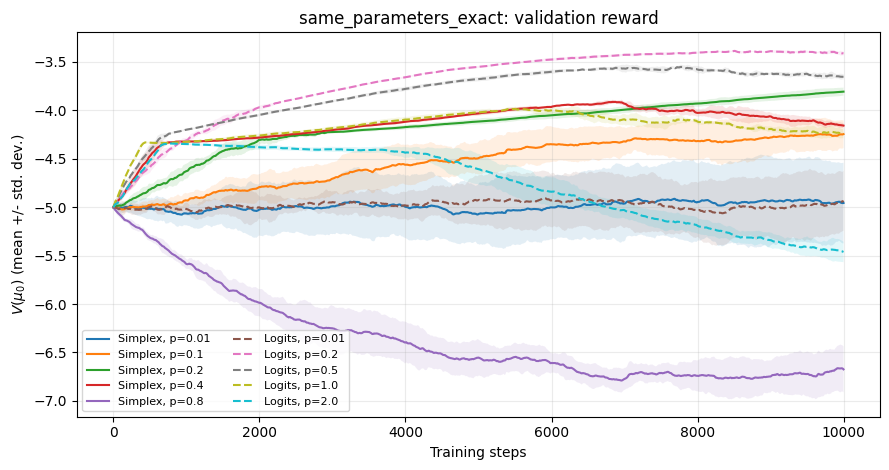

value_mean  value_std  policy_error_st_0_mean  \
algorithm parameter                                                  
Logits    0.01        -4.931893   0.308746                0.288808   
          0.20        -3.411909   0.021432                0.007003   
          0.50        -3.653657   0.028061                0.048411   
          1.00        -4.243089   0.045411                0.184384   
          2.00        -5.462406   0.106478                0.435727   
Simplex   0.01        -4.956939   0.416137                0.313175   
          0.10        -4.245609   0.142646                0.254820   
          0.20        -3.806921   0.043415                0.151168   
          0.40        -4.157317   0.031977                0.165802   
          0.80        -6.674162   0.237444                0.142157   

                     policy_error_st_0_std  policy_error_st_1_mean  \
algorithm parameter                                                  
Logits    0.01                    0.019589                0.241316   
          0.20                    0.003437                0.003453   
          0.50                    0.004078                0.009588   
          1.00                    0.007427                0.010724   
          2.00                    0.021858                0.018891   
Simplex   0.01                    0.025452                0.250195   
          0.10                    0.019592                0.170900   
          0.20                    0.010597                0.050713   
          0.40                    0.007046                0.010196   
          0.80                    0.016392                0.334632   

                     policy_error_st_1_std  policy_error_mean_mean  \
algorithm parameter                                                  
Logits    0.01                    0.020938                0.265062   
          0.20                    0.002273                0.005228   
          0.50                    0.002974                0.028999   
          1.00                    0.005408                0.097554   
          2.00                    0.010674                0.227309   
Simplex   0.01                    0.027621                0.281685   
          0.10                    0.023015                0.212860   
          0.20                    0.009882                0.100940   
          0.40                    0.005090                0.087999   
          0.80                    0.019129                0.238395   

                     policy_error_mean_std  flow_error_mean  flow_error_std  \
algorithm parameter                                                           
Logits    0.01                    0.010222         0.079319        0.015502   
          0.20                    0.001425         0.002549        0.001044   
          0.50                    0.002050         0.014373        0.001372   
          1.00                    0.003107         0.043075        0.002210   
          2.00                    0.009277         0.101831        0.005112   
Simplex   0.01                    0.012694         0.080541        0.020881   
          0.10                    0.021110         0.044765        0.007223   
          0.20                    0.010212         0.022196        0.002225   
          0.40                    0.002051         0.038911        0.001558   
          0.80                    0.015180         0.166145        0.011731   

                     runtime_seconds_mean  episodes_completed_mean  \
algorithm parameter                                                  
Logits    0.01                 127.864601                  10000.0   
          0.20                 140.410814                  10000.0   
          0.50                 172.094186                  10000.0   
          1.00                 153.363801                  10000.0   
          2.00                 130.272503                  10000.0   
Simplex   0.01                  69.452838                  

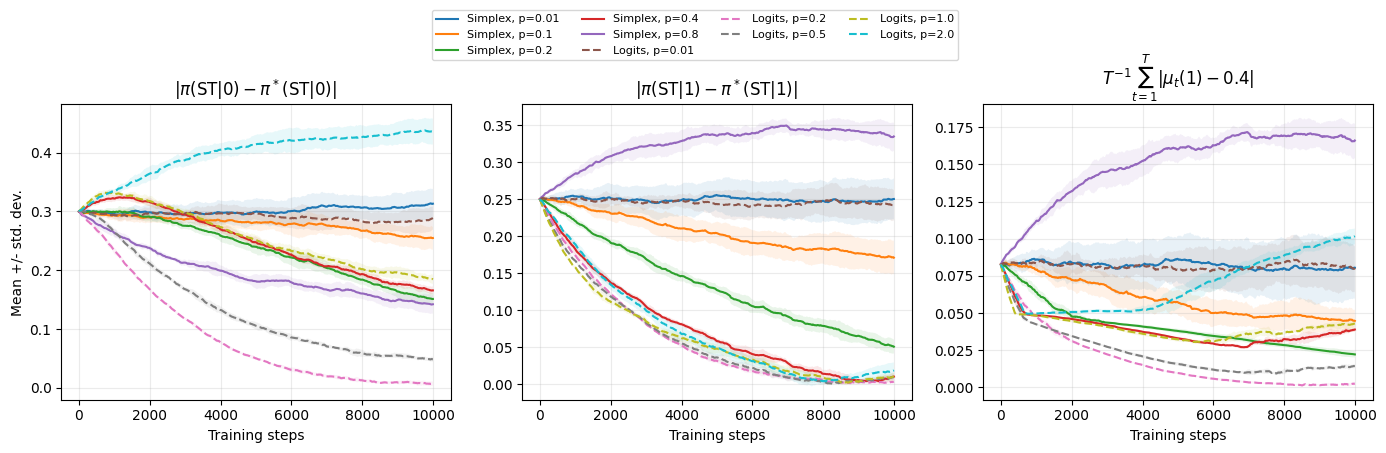

,experiment,flow_mode,T,flow_particles,algorithm,parameter,runs,samples_per_run,tv_mean,tv_p90,tv_p99,tv_max,simulator_transitions_per_update,pathwise_bound,simplex_violation_count,simplex_min_slack,logit_reference_size,logit_mean_over_reference
0,same_parameters_exact,exact,2,0,Simplex,0.01,5,20000,0.002227,0.004484,0.006673,0.007944,420,0.01,0.0,0.002056,NaN,NaN
1,same_parameters_exact,exact,2,0,Simplex,0.10,5,20000,0.022510,0.045579,0.066723,0.078706,420,0.10,0.0,0.021294,NaN,NaN
2,same_parameters_exact,exact,2,0,Simplex,0.20,5,20000,0.046341,0.094558,0.133598,0.157258,420,0.20,0.0,0.042742,NaN,NaN
3,same_parameters_exact,exact,2,0,Simplex,0.40,5,20000,0.096193,0.195264,0.267225,0.315935,420,0.40,0.0,0.084065,NaN,NaN
4,same_parameters_exact,exact,2,0,Simplex,0.80,5,20000,0.180470,0.365859,0.534738,0.630675,420,0.80,0.0,0.169325,NaN,NaN
5,same_parameters_exact,exact,2,0,Logits,0.01,5,20000,0.002461,0.005176,0.008562,0.016132,6400,NaN,NaN,NaN,0.005,0.492248
6,same_parameters_exact,exact,2,0,Logits,0.20,5,20000,0.047705,0.100114,0.161946,0.289058,6400,NaN,NaN,NaN,0.100,0.477051
7,same_parameters_exact,exact,2,0,Logits,0.50,5,20000,0.113734,0.236778,0.376800,0.621161,6400,NaN,NaN,NaN,0.250,0.454938
8,same_parameters_exact,exact,2,0,Logits,1.00,5,20000,0.200289,0.413653,0.606739,0.786429,6400,NaN,NaN,NaN,0.500,0.400578
9,same_parameters_exact,exact,2,0,Logits,2.00,5,20000,0.298854,0.643500,0.780795,0.799987,6400,NaN,NaN,NaN,1.000,0.298854


In [11]:
show_twostate_results(exact_equal_parameters, twostate_calibration)
exact_equal_parameters_perturbation_size = scenario_perturbation_size_summary(
    exact_equal_parameters,
    config,
    "same_parameters_exact",
    samples_per_run=perturbation_tv_samples_per_run,
    tolerance=perturbation_tv_tolerance,
)
display_perturbation_size_summary(exact_equal_parameters_perturbation_size)


## Experiment 2: Exact Flow, Equal Simulator Budget

Logits uses `(B, n) = (200, 10)`. Simplex uses `(B, n) = (2800, 400)`, so both estimators spend `6400` simulated transitions per policy update for `T = 2`.


In [12]:
exact_equal_budget = run_twostate_scenario(
    "equal_budget_exact",
    config,
    simplex_lambdas,
    logit_epsilons,
    equal_simulator_budgets,
    twostate_run_plans,
    flow_mode="exact",
    flow_particles=0,
    train_horizon=train_horizon,
    validation_horizon=validation_horizon,
    early_stopping_patience=early_stopping_patience,
    max_runtime_seconds=max_runtime_seconds,
)


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,exact,0,6400,1.0
Logits,200,10,2,exact,0,6400,1.0


equal_budget_exact Simplex p=0.01 run=0: 100%|██████████| 10000/10000 [01:19<00:00, 125.85it/s, grad=160, value=-4.814]  


equal_budget_exact Simplex p=0.01 run=0 value=-4.81366 cost/update=6400 runtime=1m 19s


equal_budget_exact Simplex p=0.01 run=1: 100%|██████████| 10000/10000 [01:18<00:00, 126.83it/s, grad=6.35, value=-4.288] 


equal_budget_exact Simplex p=0.01 run=1 value=-4.28787 cost/update=6400 runtime=1m 18s


...

equal_budget_exact Logits p=2.0 run=2 value=-5.40364 cost/update=6400 runtime=2m 43s


equal_budget_exact Logits p=2.0 run=3: 100%|██████████| 10000/10000 [02:44<00:00, 60.91it/s, grad=0.704, value=-5.438]


equal_budget_exact Logits p=2.0 run=3 value=-5.43799 cost/update=6400 runtime=2m 44s


equal_budget_exact Logits p=2.0 run=4: 100%|██████████| 10000/10000 [02:17<00:00, 72.57it/s, grad=0.101, value=-5.435] 

equal_budget_exact Logits p=2.0 run=4 value=-5.43527 cost/update=6400 runtime=2m 17s
equal_budget_exact Logits p=2.0 completed in 13m 16s


In [13]:
exact_equal_budget_gradient_study = run_twostate_diagnostics(
    exact_equal_budget,
    config,
    simplex_lambdas,
    logit_epsilons,
    twostate_run_plans,
    repetitions=diagnostic_repetitions,
)
display(exact_equal_budget_gradient_study.round(6))


,label,algorithm,flow_mode,flow_particles,parameter,repetitions,B,n_aux_or_inner,oracle_grad_norm,mean_grad_norm,bias_norm,covariance_trace,mse,cosine_to_oracle,simulator_transitions_per_estimate,simulator_transitions
0,initial,Simplex,exact,0,0.01,64,2800,400,3.337381,11.237783,14.530060,4589.455755,4728.868142,-0.982499,6400,409600
1,initial,Simplex,exact,0,0.10,64,2800,400,3.337381,2.217148,1.127415,11.863260,12.948962,0.998909,6400,409600
2,initial,Simplex,exact,0,0.20,64,2800,400,3.337381,2.343502,0.996141,2.458528,3.412411,0.999712,6400,409600
3,initial,Simplex,exact,0,0.40,64,2800,400,3.337381,1.132573,2.205282,0.072496,4.934631,0.999723,6400,409600
4,initial,Simplex,exact,0,0.80,64,2800,400,3.337381,0.016917,3.353272,0.002880,11.247265,-0.939041,6400,409600
5,initial,Logits,exact,0,0.01,64,200,10,3.337381,26.562442,23.276044,16638.129111,16919.932574,0.986628,6400,409600
6,initial,Logits,exact,0,0.20,64,200,10,3.337381,2.282414,1.059021,0.654449,1.765748,0.999437,6400,409600
7,initial,Logits,exact,0,0.50,64,200,10,3.337381,1.149647,2.192536,0.260173,5.063321,0.997259,6400,409600
8,initial,Logits,exact,0,1.00,64,200,10,3.337381,0.683161,2.654229,0.147559,7.190186,0.999989,6400,409600
9,initial,Logits,exact,0,2.00,64,200,10,3.337381,0.216484,3.121756,0.197314,9.939593,0.996286,6400,409600


equal_budget_exact


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,exact,0,6400,1.0
Logits,200,10,2,exact,0,6400,1.0


,algorithm,parameter,tv_mean,tv_median,tv_std,tv_p10,tv_p90
0,Simplex,0.01,0.0026,0.0023,0.0018,0.0004,0.0052
1,Simplex,0.10,0.0257,0.0227,0.0180,0.0043,0.0518
2,Simplex,0.20,0.0513,0.0454,0.0359,0.0085,0.1035
3,Simplex,0.40,0.1027,0.0908,0.0718,0.0171,0.2070
4,Simplex,0.80,0.2054,0.1816,0.1436,0.0342,0.4141
5,Logits,0.01,0.0022,0.0018,0.0018,0.0003,0.0047
6,Logits,0.20,0.0438,0.0351,0.0357,0.0061,0.0935
7,Logits,0.50,0.1061,0.0855,0.0854,0.0152,0.2253
8,Logits,1.00,0.1923,0.1580,0.1474,0.0302,0.4062
9,Logits,2.00,0.2985,0.2587,0.2049,0.0594,0.6048


radius  value_mean  value_std
algorithm parameter                                 
Logits    0.01       0.002200   -4.931893   0.308746
          0.20       0.043767   -3.411909   0.021432
          0.50       0.106082   -3.653657   0.028061
          1.00       0.192312   -4.243391   0.045749
          2.00       0.298535   -5.462280   0.106486
Simplex   0.01       0.002567   -4.666374   0.282446
          0.10       0.025669   -3.581965   0.019260
          0.20       0.051339   -3.816174   0.016177
          0.40       0.102677   -4.382434   0.016090
          0.80       0.205355   -6.074478   0.060853

value_mean_interp
algorithm matched_tv_radius                   
Logits    0.002567                   -4.918458
          0.036365                   -3.682578
          0.070163                   -3.514310
          0.103961                   -3.645426
          0.137759                   -3.870295
          0.171557                   -4.101442
          0.205355                   -4.393050
Simplex   0.002567                   -4.666374
          0.036365                   -3.679552
          0.070163                   -4.023803
          0.103961                   -4.403584
          0.137759                   -4.960549
          0.171557                   -5.517514
          0.205355                   -6.074478

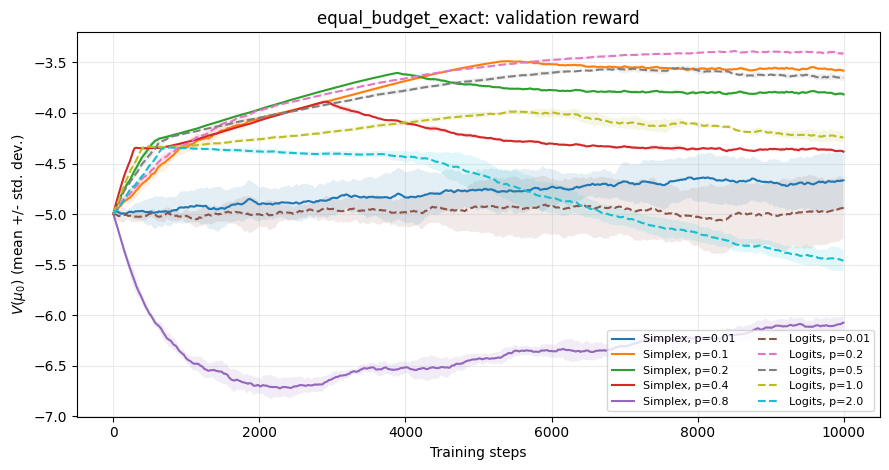

value_mean  value_std  policy_error_st_0_mean  \
algorithm parameter                                                  
Logits    0.01        -4.931893   0.308746                0.288808   
          0.20        -3.411909   0.021432                0.007003   
          0.50        -3.653657   0.028061                0.048411   
          1.00        -4.243391   0.045749                0.184329   
          2.00        -5.462280   0.106486                0.435710   
Simplex   0.01        -4.666374   0.282446                0.256713   
          0.10        -3.581965   0.019260                0.020343   
          0.20        -3.816174   0.016177                0.043664   
          0.40        -4.382434   0.016090                0.099504   
          0.80        -6.074478   0.060853                0.011134   

                     policy_error_st_0_std  policy_error_st_1_mean  \
algorithm parameter                                                  
Logits    0.01                    0.019589                0.241316   
          0.20                    0.003437                0.003453   
          0.50                    0.004078                0.009588   
          1.00                    0.007395                0.010778   
          2.00                    0.021720                0.018887   
Simplex   0.01                    0.008642                0.210582   
          0.10                    0.001346                0.014184   
          0.20                    0.000845                0.028312   
          0.40                    0.001503                0.062460   
          0.80                    0.003268                0.248749   

                     policy_error_st_1_std  policy_error_mean_mean  \
algorithm parameter                                                  
Logits    0.01                    0.020938                0.265062   
          0.20                    0.002273                0.005228   
          0.50                    0.002974                0.028999   
          1.00                    0.005451                0.097553   
          2.00                    0.010673                0.227299   
Simplex   0.01                    0.020798                0.233648   
          0.10                    0.002347                0.017263   
          0.20                    0.002020                0.035988   
          0.40                    0.001947                0.080982   
          0.80                    0.006207                0.129942   

                     policy_error_mean_std  flow_error_mean  flow_error_std  \
algorithm parameter                                                           
Logits    0.01                    0.010222         0.079319        0.015502   
          0.20                    0.001425         0.002549        0.001044   
          0.50                    0.002050         0.014373        0.001372   
          1.00                    0.003099         0.043090        0.002226   
          2.00                    0.009231         0.101824        0.005113   
Simplex   0.01                    0.007124         0.066001        0.014229   
          0.10                    0.000845         0.010869        0.000942   
          0.20                    0.000630         0.022313        0.000789   
          0.40                    0.000874         0.049875        0.000781   
          0.80                    0.003361         0.136535        0.003020   

                     runtime_seconds_mean  episodes_completed_mean  \
algorithm parameter                                                  
Logits    0.01                 182.888708                  10000.0   
          0.20                 169.891483                  10000.0   
          0.50                 174.122044                  10000.0   
          1.00                 181.561852                  10000.0   
          2.00                 159.193719                  10000.0   
Simplex   0.01                  78.654681                  

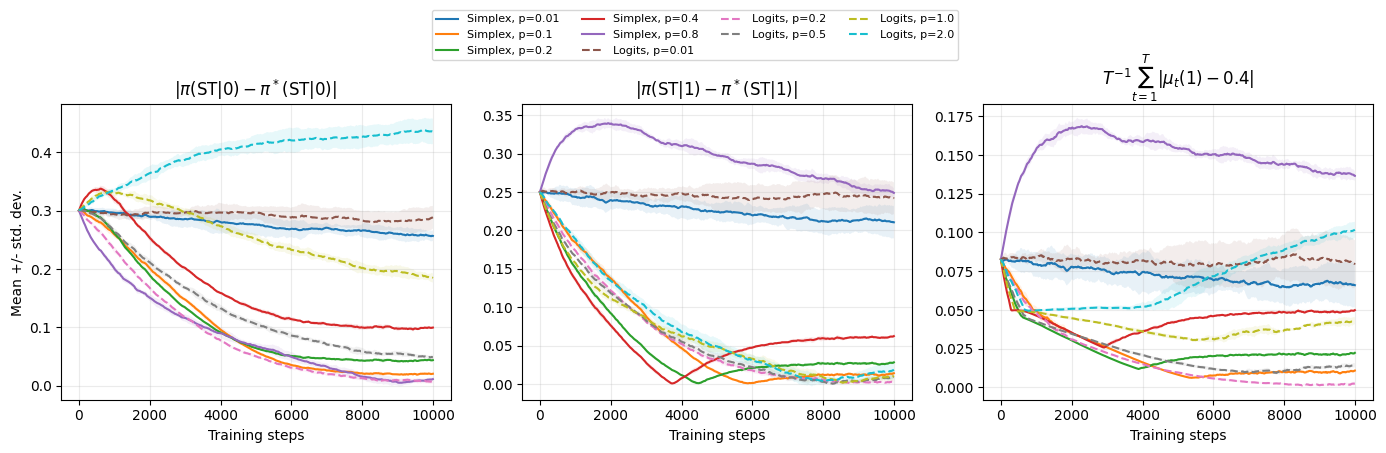

,experiment,flow_mode,T,flow_particles,algorithm,parameter,runs,samples_per_run,tv_mean,tv_p90,tv_p99,tv_max,simulator_transitions_per_update,pathwise_bound,simplex_violation_count,simplex_min_slack,logit_reference_size,logit_mean_over_reference
0,equal_budget_exact,exact,2,0,Simplex,0.01,5,20000,0.002229,0.004489,0.006673,0.007944,6400,0.01,0.0,0.002056,NaN,NaN
1,equal_budget_exact,exact,2,0,Simplex,0.10,5,20000,0.023273,0.047355,0.066723,0.078706,6400,0.10,0.0,0.021294,NaN,NaN
2,equal_budget_exact,exact,2,0,Simplex,0.20,5,20000,0.047061,0.095978,0.133598,0.157258,6400,0.20,0.0,0.042742,NaN,NaN
3,equal_budget_exact,exact,2,0,Simplex,0.40,5,20000,0.097417,0.197295,0.267225,0.315935,6400,0.40,0.0,0.084065,NaN,NaN
4,equal_budget_exact,exact,2,0,Simplex,0.80,5,20000,0.177344,0.356465,0.534738,0.630675,6400,0.80,0.0,0.169325,NaN,NaN
5,equal_budget_exact,exact,2,0,Logits,0.01,5,20000,0.002461,0.005176,0.008562,0.016132,6400,NaN,NaN,NaN,0.005,0.492248
6,equal_budget_exact,exact,2,0,Logits,0.20,5,20000,0.047705,0.100114,0.161946,0.289058,6400,NaN,NaN,NaN,0.100,0.477051
7,equal_budget_exact,exact,2,0,Logits,0.50,5,20000,0.113734,0.236778,0.376800,0.621161,6400,NaN,NaN,NaN,0.250,0.454938
8,equal_budget_exact,exact,2,0,Logits,1.00,5,20000,0.200287,0.413658,0.606759,0.786429,6400,NaN,NaN,NaN,0.500,0.400575
9,equal_budget_exact,exact,2,0,Logits,2.00,5,20000,0.298855,0.643504,0.780795,0.799987,6400,NaN,NaN,NaN,1.000,0.298855


In [14]:
show_twostate_results(exact_equal_budget, twostate_calibration)
exact_equal_budget_perturbation_size = scenario_perturbation_size_summary(
    exact_equal_budget,
    config,
    "equal_budget_exact",
    samples_per_run=perturbation_tv_samples_per_run,
    tolerance=perturbation_tv_tolerance,
)
display_perturbation_size_summary(exact_equal_budget_perturbation_size)


## Experiment 3: Particle Flow, Equal Simulator Budget, T in {2, 5, 10}

Both estimators condition on the same one-per-update empirical approximation of the unperturbed population flow with `flow_particles = 200`. For each horizon, the simplex `(B, n)` pair is chosen to match the logits simulator-transition budget while preserving the T=2 main-to-auxiliary ratio.


In [15]:
particle_horizon_scenarios = {}
particle_horizon_run_plans = {}
particle_horizon_configs = {}
for horizon in particle_horizons:
    horizon_config = TwoStateConfig(
        device=device,
        dtype=DTYPE,
        T=horizon,
        n_train=config.n_train,
        training_runs=config.training_runs,
        validate_every=config.validate_every,
    )
    horizon_plans = prepare_paired_run_plans(horizon_config, seed_base=41_000 + 100 * horizon)
    particle_horizon_configs[horizon] = horizon_config
    particle_horizon_run_plans[horizon] = horizon_plans
    particle_horizon_scenarios[horizon] = run_twostate_scenario(
        f"equal_budget_particle_T_{horizon}",
        horizon_config,
        simplex_lambdas,
        logit_epsilons,
        particle_equal_budget_for_horizon(horizon),
        horizon_plans,
        flow_mode="particle",
        flow_particles=particle_flow_particles,
        train_horizon=horizon,
        validation_horizon=horizon,
        early_stopping_patience=early_stopping_patience,
        max_runtime_seconds=max_runtime_seconds,
    )


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,particle,200,6800,1.0
Logits,200,10,2,particle,200,6800,1.0


equal_budget_particle_T_2 Simplex p=0.01 run=0:   8%|▊         | 760/10000 [00:07<01:35, 97.01it/s, grad=10.2, value=-4.838]  


KeyboardInterrupt: 

In [ ]:
particle_horizon_gradient_studies = {}
for horizon, scenario in particle_horizon_scenarios.items():
    horizon_config = particle_horizon_configs[horizon]
    particle_horizon_gradient_studies[horizon] = run_twostate_diagnostics(
        scenario,
        horizon_config,
        simplex_lambdas,
        logit_epsilons,
        particle_horizon_run_plans[horizon],
        repetitions=diagnostic_repetitions,
    )
    display(particle_horizon_gradient_studies[horizon].assign(T=horizon).round(6))


In [ ]:
particle_horizon_summary = pd.concat(
    [
        scenario_summary_table(scenario, f"equal_budget_particle_T_{horizon}", horizon=horizon)
        for horizon, scenario in particle_horizon_scenarios.items()
    ],
    ignore_index=True,
)
particle_horizon_best = (
    particle_horizon_summary
    .sort_values(["T", "algorithm", "value_mean"], ascending=[True, True, False])
    .groupby(["T", "algorithm"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(particle_horizon_summary.round(6))
display(particle_horizon_best.round(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for algorithm_name, group in particle_horizon_best.groupby("algorithm"):
    ordered = group.sort_values("T")
    axes[0].plot(ordered["T"], ordered["value_mean"], marker="o", label=algorithm_name)
    axes[1].plot(ordered["T"], ordered["flow_error_mean"], marker="o", label=algorithm_name)
axes[0].set_title("Best validation value")
axes[0].set_ylabel(r"$V(\mu_0)$")
axes[1].set_title("Best flow tracking error")
axes[1].set_ylabel(r"$T^{-1}\sum_{t=1}^{T}|\mu_t(1)-0.4|$")
for ax in axes:
    ax.set_xlabel("Horizon T")
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(particle_horizons), figsize=(15, 4), sharey=True)
for ax, horizon in zip(axes, particle_horizons):
    scenario = particle_horizon_scenarios[horizon]
    best_rows = particle_horizon_best[particle_horizon_best["T"] == horizon]
    for _, row in best_rows.iterrows():
        algorithm_name = row["algorithm"]
        parameter = float(row["parameter"])
        runs = scenario["results"][algorithm_name][parameter]
        episodes, values = aligned_validation_history(runs)
        ax.plot(episodes, values.mean(axis=0), label=f"{algorithm_name}, p={parameter:g}")
    ax.set_title(f"T={horizon}")
    ax.set_xlabel("Training steps")
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r"$V(\mu_0)$")
axes[-1].legend(loc="best")
fig.tight_layout()
plt.show()


In [ ]:
particle_horizon_perturbation_size_studies = {}
for horizon, scenario in particle_horizon_scenarios.items():
    particle_horizon_perturbation_size_studies[horizon] = scenario_perturbation_size_summary(
        scenario,
        particle_horizon_configs[horizon],
        f"equal_budget_particle_T_{horizon}",
        samples_per_run=perturbation_tv_samples_per_run,
        tolerance=perturbation_tv_tolerance,
    )

particle_perturbation_size_summary = pd.concat(
    particle_horizon_perturbation_size_studies.values(),
    ignore_index=True,
)
display_perturbation_size_summary(particle_perturbation_size_summary)


## Final Summary

The final tables collect all experiment-level metrics and all gradient diagnostics with explicit experiment labels, flow mode, horizon, particle count, algorithm, perturbation parameter, and simulator cost.


In [ ]:
cross_protocol_summary = pd.concat(
    [
        scenario_summary_table(exact_equal_parameters, "same_parameters_exact", horizon=train_horizon),
        scenario_summary_table(exact_equal_budget, "equal_budget_exact", horizon=train_horizon),
        particle_horizon_summary,
    ],
    ignore_index=True,
)

diagnostic_tables = [
    exact_equal_parameters_gradient_study.assign(experiment="same_parameters_exact", T=train_horizon),
    exact_equal_budget_gradient_study.assign(experiment="equal_budget_exact", T=train_horizon),
]
diagnostic_tables.extend(
    study.assign(experiment=f"equal_budget_particle_T_{horizon}", T=horizon)
    for horizon, study in particle_horizon_gradient_studies.items()
)
all_gradient_diagnostics = pd.concat(diagnostic_tables, ignore_index=True)
all_gradient_diagnostics = all_gradient_diagnostics[
    ["experiment", "T"] + [column for column in all_gradient_diagnostics.columns if column not in {"experiment", "T"}]
]

perturbation_size_tables = [
    exact_equal_parameters_perturbation_size,
    exact_equal_budget_perturbation_size,
]
perturbation_size_tables.extend(
    particle_horizon_perturbation_size_studies[horizon]
    for horizon in particle_horizons
)
all_perturbation_size_summaries = pd.concat(perturbation_size_tables, ignore_index=True)

display(cross_protocol_summary.round(6))
display(all_gradient_diagnostics.round(6))
display_perturbation_size_summary(all_perturbation_size_summaries)
